<a href="https://colab.research.google.com/github/aditya-r21/Finance/blob/main/HousingPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preparation**

In [ ]:
import pandas as pd
df = pd.read_csv('BostonHousing.csv')
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
df.describe() # To understand the structure

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
print(df.isnull().sum()) # Check for missing values

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [ ]:
df['rm'].fillna(df['rm'].mean(), inplace=True) # replace missing values of rm with the average of the column
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [ ]:
x = df.drop('medv', axis=1)  # Assuming 'medv(Median Value of owner-occupied homes)' is the target or dependent variable
y = df['medv']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets

# **Model Implementation**

In [ ]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression() # Create the Regression Model
linear_model.fit(x_train, y_train) # Train the Regression Model

LinearRegression()

In [ ]:
y_pred = linear_model.predict(x_test) # Predicting the target variable on training dataset
df1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df1

,Actual,Predicted
173,23.6,28.981419
274,32.4,36.014232
491,13.6,14.824309
72,22.8,25.022936
452,16.1,18.770774
...,...,...
412,17.9,-0.157994
436,9.6,13.683250
411,17.2,16.175373
86,22.5,22.260247


# **Model Evaluation**

## **Linear Regression**

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Linear Regression R-squared: {r2}")
print(f"Linear Regression Mean Squared Error: {mse}")
print(f"Linear Regression Root Mean Squared Error: {rmse}")

Linear Regression R-squared: 0.6672089705941906
Linear Regression Mean Squared Error: 24.404825188146287
Linear Regression Root Mean Squared Error: 4.940124005340988


## **Other Models**

In [ ]:
# To find out best alpha value for Ridge and Lasso Models
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
ridge_params = {'alpha': [0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5)
ridge_grid.fit(x_train, y_train)
print(f"Best Ridge alpha: {ridge_grid.best_params_['alpha']}")
lasso = Lasso()
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5)
lasso_grid.fit(x_train, y_train)
print(f"Best Lasso alpha: {lasso_grid.best_params_['alpha']}")

Best Ridge alpha: 0.1
Best Lasso alpha: 0.001


### **Ridge Model**

In [ ]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train, y_train)
ridge_pred = ridge_model.predict(x_test)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print(f"Ridge Regression R-squared: {ridge_r2}")
print(f"Ridge Regression Mean Squared Error: {ridge_mse}")
print(f"Ridge Regression RMSE: {ridge_rmse}")

Ridge Regression R-squared: 0.6670990218950748
Ridge Regression Mean Squared Error: 24.41288814220601
Ridge Regression RMSE: 4.940940005930654


### **Lasso Model**

In [ ]:
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(x_train, y_train)
lasso_pred = lasso_model.predict(x_test)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print(f"Lasso Regression R-squared: {lasso_r2}")
print(f"Lasso Regression Mean Squared Error: {lasso_mse}")
print(f"Lasso Regression RMSE: {lasso_rmse}")

Lasso Regression R-squared: 0.6672487381609442
Lasso Regression Mean Squared Error: 24.40190888202917
Lasso Regression RMSE: 4.939828831248019


## **Model Comparison**

In [ ]:
cp = {'Linear Regression': [r2, mse, rmse], 'Ridge': [ridge_r2, ridge_mse, ridge_rmse], 'Lasso': [lasso_r2, lasso_mse, lasso_rmse]}
row_names = ['R-squared', 'Mean Squared Error', 'Root Mean Squared Error']
df2 = pd.DataFrame(cp, index=row_names)
df2

,Linear Regression,Ridge,Lasso
R-squared,0.667209,0.667099,0.667249
Mean Squared Error,24.404825,24.412888,24.401909
Root Mean Squared Error,4.940124,4.940940,4.939829


* **Lasso Regression** appears to have a slight edge over the other models, with the highest R-squared, lowest MSE, and lowest RMSE. Given the minimal differences, it should be considered the best model in this example because it slightly outperforms the others in all three metrics. Additionally, Lasso can also perform feature selection by shrinking some coefficients to zero, which can be beneficial in cases of multicollinearity or when simplifying the model is important.

* **Linear Regression** is almost as good as Lasso in this case, and it might be considered the best if you want a straightforward model without regularization.

* **Ridge Regression** performs nearly identically to the other models but shows slightly worse performance in all three metrics.

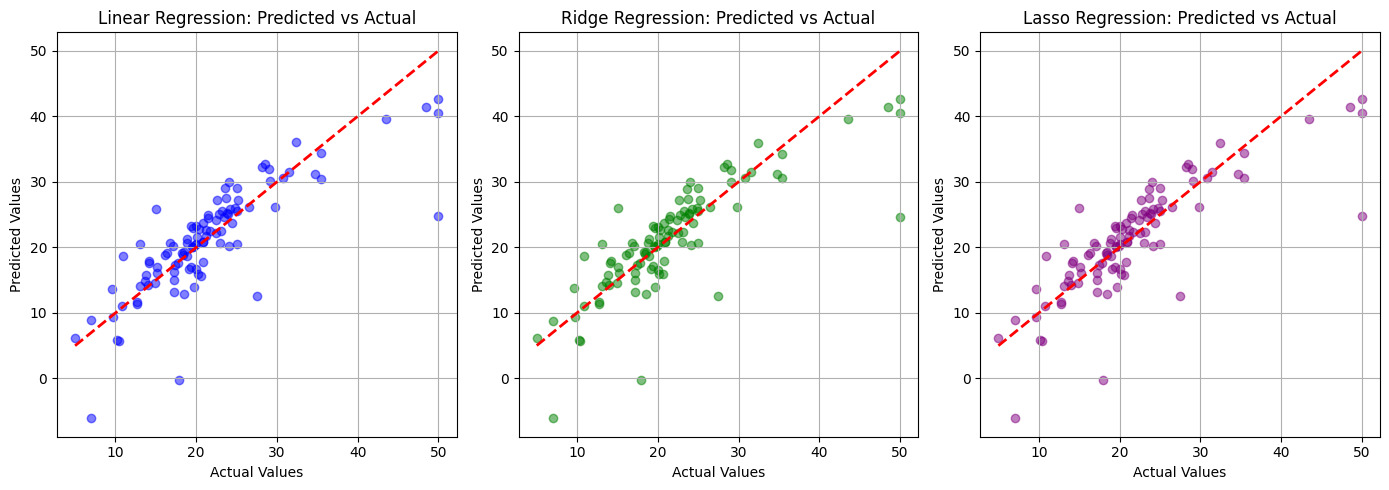

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.figure(figsize=(14, 5))

# Plot Linear Regression Predictions
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Linear Regression: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

# Plot Ridge Regression Predictions
plt.subplot(1, 3, 2)
plt.scatter(y_test, ridge_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Ridge Regression: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

# Plot Lasso Regression Predictions
plt.subplot(1, 3, 3)
plt.scatter(y_test, lasso_pred, color='purple', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Lasso Regression: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

plt.tight_layout()
plt.show()

# **Model Diagnostics**

## **Variance Inflation Factor (VIF)**

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add a constant to x for the intercept
x_with_const = sm.add_constant(x_train)

# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data['Feature'] = x_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(x_with_const.values, i) for i in range(x_with_const.shape[1])]
vif_data

,Feature,VIF
0,const,582.607762
1,crim,1.713213
2,zn,2.465560
3,indus,3.880681
4,chas,1.096659
5,nox,4.469626
6,rm,1.955037
7,age,2.989418
8,dis,4.171945
9,rad,7.659290


**The Variance Inflation Factor (VIF)** quantifies the severity of multicollinearity in an ordinary least squares regression analysis. The VIF measures how much the variance of an estimated regression coefficient increases if your predictors are correlated.

* **VIF = 1:** No multicollinearity.
* **1 < VIF < 5:** Moderate multicollinearity.
* **VIF ≥ 5:** High multicollinearity.
* **VIF > 10:** Very high multicollinearity, which requires corrective actions.

## **Correlation Matrix & Eigenvalues**

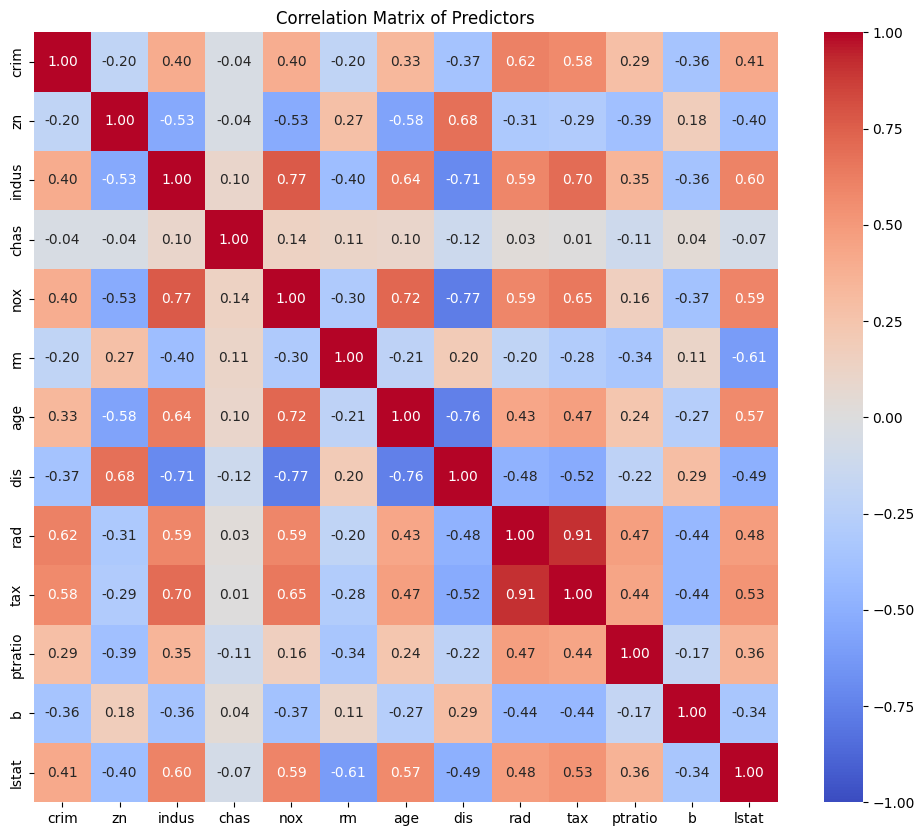

In [ ]:
corr_matrix = x_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Predictors')
plt.show()

Pairs of predictors with high absolute correlation values (> 0.8 or < -0.8). These indicate that the predictors may be providing redundant information, which can lead to multicollinearity.

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)
eigenvalues_df = pd.DataFrame({'Parameter': corr_matrix.columns,'Eigenvalue': eigenvalues})
eigenvalues_df = eigenvalues_df.sort_values(by='Eigenvalue', ascending=False).reset_index(drop=True)
eigenvalues_df

,Parameter,Eigenvalue
0,crim,6.028328
1,zn,1.482384
2,indus,1.269767
3,chas,0.871268
4,nox,0.851436
5,rm,0.665018
6,age,0.534004
7,dis,0.395341
8,tax,0.271008
9,ptratio,0.220533


* If the correlation matrix has very small eigenvalues, it indicates that some of the predictor variables are nearly collinear. This means that some predictors can be approximately expressed as linear combinations of others.
* Small eigenvalues suggest that the corresponding principal components explain a very small portion of the variance. If there are very small eigenvalues (close to zero), this indicates potential multicollinearity issues.

## **Hypothesis Testing on Coefficients**

In [ ]:
model = sm.OLS(y_train, x_with_const).fit()

print("\nOLS Regression Results:\n")
print(model.summary())


OLS Regression Results:

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     90.18
Date:                Mon, 09 Sep 2024   Prob (F-statistic):          9.27e-109
Time:                        16:11:26   Log-Likelihood:                -1194.7
No. Observations:                 404   AIC:                             2417.
Df Residuals:                     390   BIC:                             2474.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.2964     

* **Coefficients (Coef.):** These are the estimated values of the coefficients for each predictor. The sign (positive or negative) indicates the direction of the relationship with the dependent variable (medv).

* **Standard Errors (Std.Err.):** These are the standard errors associated with each coefficient. They measure the variability in the estimate of the coefficient.

* **t-Values:** The t-statistic is calculated as the coefficient divided by its standard error. It measures how many standard errors the coefficient is away from zero.

* **p-Values:** The p-values indicate the significance level of the coefficients:
** If the *p-value < 0.05,* the coefficient is statistically significant at the 95% confidence level.
** If the *p-value ≥ 0.05,* the coefficient is not statistically significant.

* **Confidence Intervals [0.025, 0.975]:** This shows the 95% confidence interval for each coefficient. If zero is not within this interval, the coefficient is considered statistically significant.

## **Model Assumptions**

### **Linearity and Homoscedasticity**

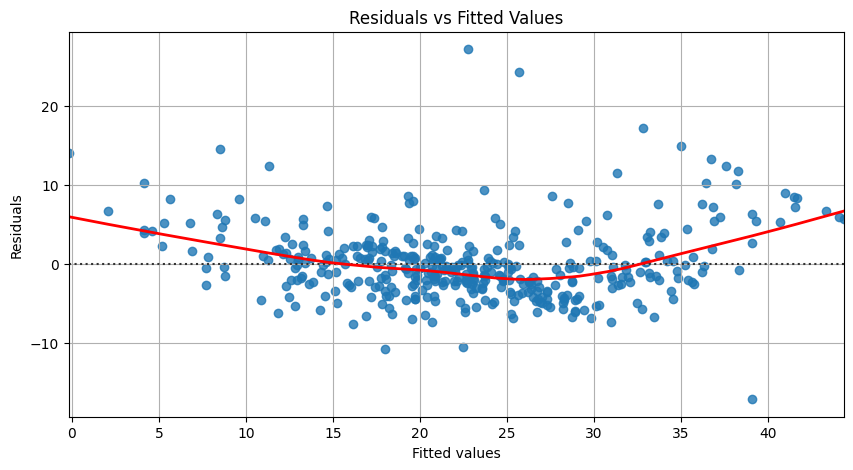

In [ ]:
plt.figure(figsize=(10, 5))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid()
plt.show()

* **Linearity :** The red lcurve in the plot shows a clear curvature, indicating that the relationship between the predictor variables and the dependent variable is likely non-linear. If the model were well-fitted and linear, the residuals would be scattered evenly around the horizontal line at 0, without any distinct pattern. This suggests that a simple linear model may not be sufficient and that a more complex model (e.g., polynomial regression) might be needed.

* **Homoscedasticity :** It means that the variance of the residuals should be constant across all levels of the fitted values. Here, the residuals appear to spread unevenly — being more concentrated in the middle and more dispersed at the extremes. This indicates heteroscedasticity, meaning that the error variance is not constant and varies with the fitted values, violating one of the assumptions of linear regression.

### **Normality of Residuals**

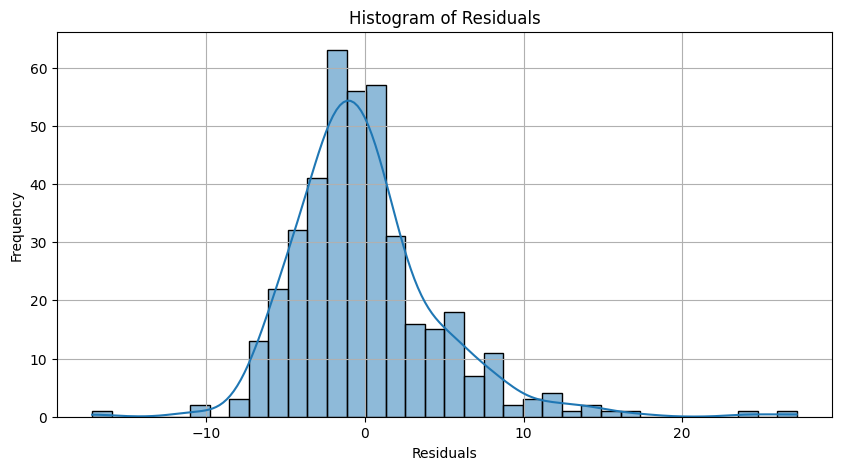

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(model.resid, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid()
plt.show()

 * For residuals to be normally distributed, the histogram should resemble a bell curve (Gaussian distribution), with most of the residuals centered around zero and symmetrically tapering off in both directions.
 * Here, the residuals are right-skewed (positively skewed).
There is a noticeable tail on the right side, where residuals greater than 10 are more frequent than would be expected in a normal distribution.
The peak is centered slightly below zero, which shows that the residuals are concentrated near zero, but the distribution is not symmetric.

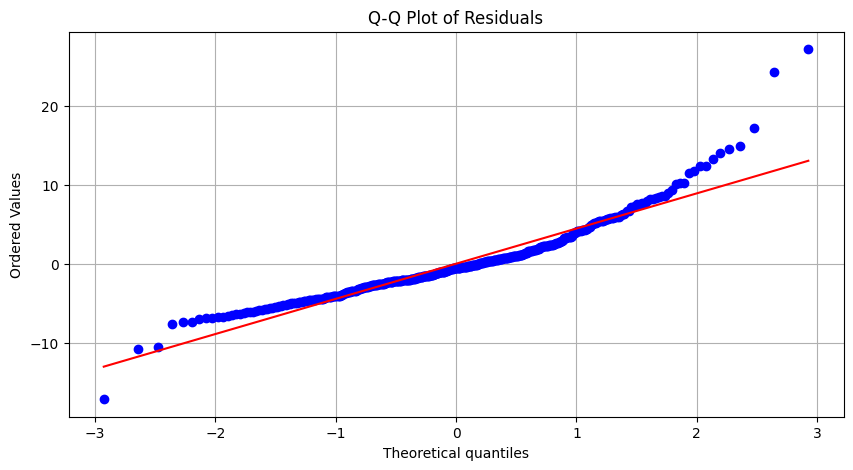

In [ ]:
from scipy.stats import probplot

plt.figure(figsize=(10, 5))
probplot(model.resid, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid()
plt.show()

* In a Q-Q plot, if the residuals follow a normal distribution, the points should lie along the red diagonal line. Deviations from this line suggest departures from normality.
* On the left side, the lower quantiles (negative residuals) deviate below the line, indicating that the left tail is heavier than expected under normality.
* On the right side, the upper quantiles (positive residuals) rise above the line, indicating that the right tail is also heavier (right-skewed).